# Imports


In [1]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import squidpy as sq
import cellcharter as cc
import scvi
import torch

from lightning.pytorch import seed_everything
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
)
from scipy.optimize import linear_sum_assignment

# Keep numerical behavior reasonably reproducible
torch.set_float32_matmul_precision("high")


# USER CONFIGURATION — edit these to match your environment


In [2]:
# =============================================================================
# USER CONFIGURATION — edit these to match your environment
# =============================================================================

# Path to cloned CellCharter repo. This is not strictly required for import if
# the package has been installed, but we keep it here to mirror your SpaCross
# notebook format and to make local editable installs/debugging explicit.
CELLCHARTER_ROOT = Path(r"/work/dal875013/projects/mocha/methods/cellcharter")

# Path to the folder containing SCE_151*.h5ad files
DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/DLPFC_10x/data")

# Output folder for benchmark results
# This single-sample notebook only writes benchmark.log, performance.parquet, and predictions.parquet.
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/CellCharter/dlpfc_cellcharter")

# All 12 DLPFC slice IDs
ALL_DLPFC_SAMPLES = [
    "151507", "151508", "151509", "151510",
    "151669", "151670", "151671", "151672",
    "151673", "151674", "151675", "151676",
]

# ----- SUBSET SELECTOR -----------------------------------------------------
# Set SAMPLES_TO_RUN to:
#   - None or "all" → run all 12 slices
#   - A list like ["151507", "151673"] → only run those slices
#   - A single string "151675" → run just that one
#
# First smoke test suggestion:
# SAMPLES_TO_RUN = "151673"
SAMPLES_TO_RUN = None

# Method name written to parquet files
METHOD_NAME = "CellCharter"

# Number of runs per slice (>1 enables variance estimation)
NUM_RUNS = 1

# Fixed number of DLPFC cortical layer clusters.
# For the standard DLPFC benchmark we use K=7.
NUM_CLUSTERS_DLPFC = 7

# Which column in adata.obs holds the ground-truth layer labels.
# Leave as None to auto-detect from common names:
#   z, layer_guess, layer_guess_reordered, Ground Truth, ground_truth, layer, Layer
GT_LABEL_COL = "z"

# =============================================================================
# CellCharter/scVI settings
# =============================================================================

# scVI dimensionality reduction, following the official CosMx transcriptomics
# tutorial logic: counts layer -> scVI -> X_scVI -> CellCharter aggregation.
COUNT_LAYER = "counts"
SCVI_LATENT_KEY = "X_scVI"
CELLCHARTER_KEY = "X_cellcharter"
CLUSTER_KEY = "spatial_cluster"

SCVI_N_LATENT = 10
SCVI_MAX_EPOCHS = None       # None lets scVI decide. For smoke test, try 50.
SCVI_EARLY_STOPPING = True
SCVI_BATCH_KEY = "sample"    # Single-sample run still has one sample category.

# Visium has many genes, so we subset to HVGs for speed/memory after saving
# raw counts in adata.layers["counts"]. This is a preprocessing adaptation.
USE_HVG = True
N_TOP_GENES = 2000

# Basic filtering, adapted from the attached SpaCross notebook and CosMx tutorial.
MIN_GENE_COUNTS = 3
MIN_CELL_COUNTS = 3

# CellCharter spatial graph + aggregation
SPATIAL_KEY = "spatial"
SAMPLE_KEY = "sample"
N_LAYERS = 3
USE_DELAUNAY = True
SPATIAL_PERCENTILE = 99
REMOVE_LONG_LINKS = True

# CellCharter GMM clustering
CELLCHARTER_CLUSTER_ON_GPU = True
CELLCHARTER_BATCH_SIZE = None    # Set e.g. 4096 if full-batch GMM uses too much memory.


# =============================================================================
# GPU / device setup
# =============================================================================
def get_device():
    """Return 'cuda:0' if a CUDA GPU is available, else 'cpu'. Logs details."""
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
        logging.info(f"[DEVICE] CUDA available — using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU detected — falling back to CPU")
    return dev

# Logging setup
def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"

    # Reset existing handlers so notebook reruns do not duplicate logs.
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(message)s",
        handlers=[
            logging.FileHandler(log_file, mode="w"),
            logging.StreamHandler(sys.stdout),
        ],
    )
    logging.info(f"[LOG] Writing log to {log_file.resolve()}")

def resolve_samples(samples_to_run):
    """Resolve SAMPLES_TO_RUN into a list of valid sample IDs."""
    if samples_to_run is None or samples_to_run == "all":
        return ALL_DLPFC_SAMPLES
    if isinstance(samples_to_run, str):
        samples = [samples_to_run]
    else:
        samples = list(samples_to_run)

    unknown = sorted(set(samples) - set(ALL_DLPFC_SAMPLES))
    if unknown:
        raise ValueError(f"Unknown DLPFC sample IDs: {unknown}")
    return samples


# Data loading  (adapted for .h5ad input)


In [3]:
# =============================================================================
# Data loading  (adapted for .h5ad input)
# =============================================================================
def detect_gt_column(adata):
    """Choose the ground-truth label column."""
    if GT_LABEL_COL is not None:
        if GT_LABEL_COL not in adata.obs:
            raise KeyError(
                f"GT_LABEL_COL='{GT_LABEL_COL}' not found. "
                f"Available obs columns: {list(adata.obs.columns)}"
            )
        return GT_LABEL_COL

    candidates = [
        "z",
        "layer_guess",
        "layer_guess_reordered",
        "Ground Truth",
        "ground_truth",
        "layer",
        "Layer",
    ]
    for col in candidates:
        if col in adata.obs:
            return col

    raise KeyError(
        "Could not auto-detect ground-truth label column. "
        f"Available obs columns: {list(adata.obs.columns)}"
    )

def _copy_matrix(X):
    """Copy dense or sparse AnnData matrix without accidentally densifying."""
    return X.copy()

def prepare_dlpfc_adata(sample_id: str):
    """
    Load and preprocess a single DLPFC .h5ad file for CellCharter.

    This mirrors the attached SpaCross notebook's DLPFC file handling:
      - read SCE_<sample>.h5ad from DATA_ROOT
      - use obs['z'] as ground truth by default
      - alias obsm['S'] -> obsm['spatial'] if needed

    Method-specific preprocessing follows the CellCharter CosMx tutorial:
      - save raw counts in adata.layers['counts']
      - normalize/log only for HVG selection and diagnostics
      - use scVI on the raw counts layer
    """
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"  [LOAD] Reading {h5ad_path}")
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")

    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()

    logging.info(
        f"  [DIAG] Loaded AnnData: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"  [DIAG] obs columns: {list(adata.obs.columns)}")
    logging.info(f"  [DIAG] obsm keys  : {list(adata.obsm.keys())}")

    # Ground truth
    gt_col = detect_gt_column(adata)
    adata.obs["layer_guess"] = adata.obs[gt_col].astype(object)
    n_labeled = int(adata.obs["layer_guess"].notna().sum())
    logging.info(
        f"  [DIAG] Using GT column '{gt_col}' "
        f"(labeled spots: {n_labeled}/{adata.n_obs})"
    )

    # Add sample metadata; this keeps the code compatible with the donor-level
    # version later and with CellCharter's sample_key/library_key logic.
    adata.obs[SAMPLE_KEY] = pd.Categorical([sample_id] * adata.n_obs)

    # This dataset often uses obsm['S'] as the spatial key instead of 'spatial'.
    if SPATIAL_KEY not in adata.obsm:
        if "S" in adata.obsm:
            adata.obsm[SPATIAL_KEY] = np.asarray(adata.obsm["S"])
            logging.info(f"  [DIAG] Aliased obsm['S'] -> obsm['{SPATIAL_KEY}']")
        else:
            raise KeyError(
                f"No spatial coordinates found in {h5ad_path}. "
                f"Available obsm keys: {list(adata.obsm.keys())}"
            )
    else:
        adata.obsm[SPATIAL_KEY] = np.asarray(adata.obsm[SPATIAL_KEY])

    logging.info(
        f"  [DIAG] spatial coords shape: {adata.obsm[SPATIAL_KEY].shape}"
    )

    # Basic count filtering, following the CosMx tutorial's filter_genes/filter_cells
    # idea but using conservative thresholds.
    sc.pp.filter_genes(adata, min_counts=MIN_GENE_COUNTS)
    sc.pp.filter_cells(adata, min_counts=MIN_CELL_COUNTS)
    logging.info(
        f"  [DIAG] After basic filtering: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )

    # Save raw count matrix for scVI before normalization/log transform.
    adata.layers[COUNT_LAYER] = _copy_matrix(adata.X)

    # Normalize/log only for HVG selection and later inspection. scVI will use
    # adata.layers[COUNT_LAYER], not the normalized X.
    sc.pp.normalize_total(adata, target_sum=1e6)
    sc.pp.log1p(adata)

    if USE_HVG:
        n_top = min(N_TOP_GENES, adata.n_vars)
        sc.pp.highly_variable_genes(
            adata,
            n_top_genes=n_top,
            flavor="seurat",
        )
        n_hvg = int(adata.var["highly_variable"].sum())
        logging.info(f"  [DIAG] HVGs selected: {n_hvg}/{adata.n_vars}")
        adata = adata[:, adata.var["highly_variable"]].copy()
        logging.info(f"  [DIAG] After HVG subset: n_vars={adata.n_vars}")

    return adata, gt_col


# Metrics helpers


In [4]:
# =============================================================================
# Metrics helpers
# =============================================================================
def clustering_accuracy(y_true, y_pred):
    """
    Clustering accuracy after optimal label matching via Hungarian algorithm.
    This is useful as a simple ACC column comparable across unsupervised runs.
    """
    y_true = pd.Series(y_true).astype(str).to_numpy()
    y_pred = pd.Series(y_pred).astype(str).to_numpy()

    true_classes = pd.Index(sorted(pd.unique(y_true)))
    pred_classes = pd.Index(sorted(pd.unique(y_pred)))

    contingency = np.zeros((len(true_classes), len(pred_classes)), dtype=np.int64)
    true_map = {c: i for i, c in enumerate(true_classes)}
    pred_map = {c: j for j, c in enumerate(pred_classes)}

    for t, p in zip(y_true, y_pred):
        contingency[true_map[t], pred_map[p]] += 1

    # Maximize correct assignments. linear_sum_assignment minimizes cost.
    row_ind, col_ind = linear_sum_assignment(-contingency)
    return contingency[row_ind, col_ind].sum() / contingency.sum()

def compute_metrics(adata, label_key="layer_guess", pred_key=CLUSTER_KEY):
    """Compute metrics on labeled spots only."""
    labeled_mask = adata.obs[label_key].notna()
    sub = adata[labeled_mask].copy()

    if sub.n_obs == 0:
        return {
            "ARI": np.nan,
            "NMI": np.nan,
            "ACC": np.nan,
            "HOM": np.nan,
            "COM": np.nan,
            "V_measure": np.nan,
        }, sub

    y_true = sub.obs[label_key].astype(str).to_numpy()
    y_pred = sub.obs[pred_key].astype(str).to_numpy()

    metrics = {
        "ARI": float(adjusted_rand_score(y_true, y_pred)),
        "NMI": float(normalized_mutual_info_score(y_true, y_pred)),
        "ACC": float(clustering_accuracy(y_true, y_pred)),
        "HOM": float(homogeneity_score(y_true, y_pred)),
        "COM": float(completeness_score(y_true, y_pred)),
        "V_measure": float(v_measure_score(y_true, y_pred)),
    }
    return metrics, sub


# Train one slice


In [5]:
# =============================================================================
# Train one slice
# =============================================================================
def train_one_slice(
    sample_id: str,
    adata,
    device: str,
    run_seed: int = 0,
):
    """
    Run CellCharter on one DLPFC slice and compute ARI/NMI/ACC.

    Method body follows the official CellCharter transcriptomics workflow:
        counts layer
        -> scVI latent representation
        -> squidpy spatial_neighbors
        -> optional CellCharter remove_long_links
        -> CellCharter aggregate_neighbors
        -> CellCharter GMM Cluster with fixed K

    Returns:
        metrics: dict of scalar metrics + timing
        pred_df: DataFrame with one row per spot:
            method, sample, spot_id, true_label, pred_label, run_seed
    """
    num_clusters = NUM_CLUSTERS_DLPFC
    logging.info(
        f"  [TRAIN] Starting CellCharter single-sample | slice={sample_id} | "
        f"k_clusters={num_clusters} | device={device} | run_seed={run_seed}"
    )

    seed_everything(run_seed, workers=True)
    scvi.settings.seed = run_seed
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run_seed)

    t0 = time.time()

    # ---------------------------------------------------------------------
    # 1) scVI dimensionality reduction
    # ---------------------------------------------------------------------
    logging.info("  [SCVI] setup_anndata")
    scvi.model.SCVI.setup_anndata(
        adata,
        layer=COUNT_LAYER,
        batch_key=SCVI_BATCH_KEY,
    )

    logging.info(
        f"  [SCVI] Training SCVI(n_latent={SCVI_N_LATENT}, "
        f"early_stopping={SCVI_EARLY_STOPPING})"
    )
    model = scvi.model.SCVI(
        adata,
        n_latent=SCVI_N_LATENT,
    )

    train_kwargs = dict(
        early_stopping=SCVI_EARLY_STOPPING,
        enable_progress_bar=True,
    )
    if SCVI_MAX_EPOCHS is not None:
        train_kwargs["max_epochs"] = SCVI_MAX_EPOCHS

    if torch.cuda.is_available():
        train_kwargs.update(dict(accelerator="gpu", devices=1))
    else:
        train_kwargs.update(dict(accelerator="cpu"))

    try:
        model.train(**train_kwargs)
    except TypeError:
        # Compatibility fallback for older/newer scvi-tools trainer signatures.
        logging.warning("  [SCVI] train_kwargs failed; retrying with minimal train()")
        model.train(
            max_epochs=SCVI_MAX_EPOCHS,
            early_stopping=SCVI_EARLY_STOPPING,
            enable_progress_bar=True,
        )

    adata.obsm[SCVI_LATENT_KEY] = model.get_latent_representation(adata).astype(np.float32)
    logging.info(f"  [DIAG] {SCVI_LATENT_KEY} shape: {adata.obsm[SCVI_LATENT_KEY].shape}")

    # ---------------------------------------------------------------------
    # 2) Spatial graph, following CellCharter tutorials
    # ---------------------------------------------------------------------
    logging.info("  [GRAPH] squidpy.gr.spatial_neighbors")
    sq.gr.spatial_neighbors(
        adata,
        library_key=SAMPLE_KEY,
        coord_type="generic",
        delaunay=USE_DELAUNAY,
        spatial_key=SPATIAL_KEY,
        percentile=SPATIAL_PERCENTILE,
    )

    if REMOVE_LONG_LINKS:
        logging.info("  [GRAPH] cellcharter.gr.remove_long_links")
        try:
            cc.gr.remove_long_links(adata)
        except Exception as e:
            logging.warning(f"  [GRAPH] remove_long_links failed; continuing. Error: {e}")

    # ---------------------------------------------------------------------
    # 3) CellCharter neighborhood aggregation
    # ---------------------------------------------------------------------
    logging.info(
        f"  [CC] aggregate_neighbors(n_layers={N_LAYERS}, use_rep={SCVI_LATENT_KEY})"
    )
    cc.gr.aggregate_neighbors(
        adata,
        n_layers=N_LAYERS,
        use_rep=SCVI_LATENT_KEY,
        out_key=CELLCHARTER_KEY,
        sample_key=SAMPLE_KEY,
    )
    logging.info(f"  [DIAG] {CELLCHARTER_KEY} shape: {adata.obsm[CELLCHARTER_KEY].shape}")

    # ---------------------------------------------------------------------
    # 4) CellCharter GMM clustering
    # ---------------------------------------------------------------------
    trainer_params = None
    if CELLCHARTER_CLUSTER_ON_GPU and torch.cuda.is_available():
        trainer_params = dict(accelerator="gpu", devices=1, enable_progress_bar=True)
    else:
        trainer_params = dict(accelerator="cpu", enable_progress_bar=True)

    logging.info("  [CC] Fitting CellCharter Cluster")
    gmm = cc.tl.Cluster(
        n_clusters=num_clusters,
        random_state=run_seed,
        batch_size=CELLCHARTER_BATCH_SIZE,
        trainer_params=trainer_params,
    )
    gmm.fit(adata, use_rep=CELLCHARTER_KEY)
    pred_labels = gmm.predict(adata, use_rep=CELLCHARTER_KEY)

    # Store as string category for clean parquet/plotting
    adata.obs[CLUSTER_KEY] = pd.Categorical(pd.Series(pred_labels, index=adata.obs_names).astype(str))

    logging.info(
        f"  [DIAG] Cluster sizes: "
        f"{adata.obs[CLUSTER_KEY].astype(str).value_counts().to_dict()}"
    )

    elapsed = time.time() - t0

    # ---------------------------------------------------------------------
    # 5) Metrics
    # ---------------------------------------------------------------------
    metric_vals, sub_adata = compute_metrics(adata, "layer_guess", CLUSTER_KEY)

    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics = {
        "method": METHOD_NAME,
        "sample": sample_id,
        "training_unit": sample_id,
        "run_seed": run_seed,
        **metric_vals,
        # Keep DIS column for compatibility with older SpaCross-style summaries.
        # CellCharter itself does not output SpaCross DIS, so leave it as NaN.
        "DIS": np.nan,
        "running_time_sec": round(elapsed, 2),
        "unit_running_time_sec": round(elapsed, 2),
        "gpu_model": gpu_name,
        "num_clusters": int(num_clusters),
        "num_spots": int(adata.n_obs),
        "num_labeled_spots": int(sub_adata.n_obs),
        "num_genes_after_hvg": int(adata.n_vars),
        "scvi_n_latent": int(SCVI_N_LATENT),
        "cellcharter_dim": int(adata.obsm[CELLCHARTER_KEY].shape[1]),
        "n_layers": int(N_LAYERS),
        "cluster_key": CLUSTER_KEY,
        "device": device,
    }

    pred_df = pd.DataFrame({
        "method": METHOD_NAME,
        "sample": sample_id,
        "training_unit": sample_id,
        "spot_id": adata.obs_names.astype(str),
        "true_label": adata.obs["layer_guess"].astype(object).values,
        "pred_label": adata.obs[CLUSTER_KEY].astype(str).values,
        "run_seed": run_seed,
    })


    return metrics, pred_df


# Main benchmark loop


In [6]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("CellCharter DLPFC Benchmarking Framework")
    logging.info("=" * 72)

    # --- Optional local repo sanity check ---
    if CELLCHARTER_ROOT.exists():
        logging.info(f"[PATHS] CELLCHARTER_ROOT = {CELLCHARTER_ROOT.resolve()}")
        # Only add if you want to use local source before installed wheel.
        if str(CELLCHARTER_ROOT.resolve()) not in sys.path:
            sys.path.insert(0, str(CELLCHARTER_ROOT.resolve()))
    else:
        logging.warning(f"[PATHS] CELLCHARTER_ROOT not found: {CELLCHARTER_ROOT}")

    # --- Device ---
    device = get_device()

    # --- Data root sanity check ---
    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    logging.info(f"[PATHS] DATA_ROOT  = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR = {OUTPUT_DIR.resolve()}")

    logging.info(f"[VERSIONS] cellcharter = {getattr(cc, '__version__', cc.__file__)}")
    logging.info(f"[VERSIONS] scvi        = {scvi.__version__}")
    logging.info(f"[VERSIONS] scanpy      = {sc.__version__}")
    logging.info(f"[VERSIONS] squidpy     = {sq.__version__}")
    logging.info(f"[VERSIONS] torch       = {torch.__version__}")

    # --- Which slices to run ---
    samples = resolve_samples(SAMPLES_TO_RUN)
    logging.info(f"[SAMPLES] Will process {len(samples)} slice(s): {samples}")
    logging.info(
        f"[SETTINGS] NUM_RUNS={NUM_RUNS} | K={NUM_CLUSTERS_DLPFC} | "
        f"SCVI_N_LATENT={SCVI_N_LATENT} | N_LAYERS={N_LAYERS} | USE_HVG={USE_HVG}"
    )

    all_metrics = []
    all_predictions = []
    failed = []

    for i, sample_id in enumerate(samples, start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(samples)}] Slice {sample_id}")
        logging.info("-" * 72)

        try:
            adata, gt_col = prepare_dlpfc_adata(sample_id)

            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")
                adata_run = adata.copy()  # avoid cross-run contamination

                metrics, pred_df = train_one_slice(
                    sample_id=sample_id,
                    adata=adata_run,
                    device=device,
                    run_seed=run,
                )
                metrics["gt_col"] = gt_col
                all_metrics.append(metrics)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Slice {sample_id}: {e}")
            failed.append({"sample": sample_id, "error": str(e)})
            continue

    # =====================================================================
    # Save outputs
    # =====================================================================
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    if all_metrics:
        performance = pd.DataFrame(all_metrics)
        performance_path = OUTPUT_DIR / "performance.parquet"
        performance.to_parquet(performance_path, index=False)
        logging.info(f"[SAVE] performance -> {performance_path}")


        logging.info("[RESULTS] Performance table:")
        logging.info("\n" + performance.to_string(index=False))
    else:
        performance = pd.DataFrame()
        logging.warning("[SAVE] No successful metrics to save.")

    if all_predictions:
        predictions = pd.concat(all_predictions, ignore_index=True)
        pred_path = OUTPUT_DIR / "predictions.parquet"
        predictions.to_parquet(pred_path, index=False)
        logging.info(f"[SAVE] predictions -> {pred_path}")

    else:
        predictions = pd.DataFrame()
        logging.warning("[SAVE] No predictions to save.")

    if failed:
        logging.warning(f"[FAILED] Some slices failed: {failed}")
    else:
        logging.info("[DONE] All requested slices completed successfully.")

    return performance, predictions, failed

# Actually run benchmark
performance, predictions, failed = run_benchmark()


2026-05-18 03:18:31,520 | INFO | [LOG] Writing log to /work/dal875013/projects/mocha/results/CellCharter/dlpfc_cellcharter/benchmark.log
2026-05-18 03:18:31,522 | INFO | ========================================================================
2026-05-18 03:18:31,523 | INFO | CellCharter DLPFC Benchmarking Framework
2026-05-18 03:18:31,524 | INFO | ========================================================================
2026-05-18 03:18:31,525 | INFO | [PATHS] CELLCHARTER_ROOT = /work/dal875013/projects/mocha/methods/cellcharter
2026-05-18 03:18:31,553 | INFO | [DEVICE] CUDA available — using cuda:0
2026-05-18 03:18:31,653 | INFO | [DEVICE] GPU name: NVIDIA A30
2026-05-18 03:18:31,654 | INFO | [DEVICE] GPU memory: 25.22 GB
2026-05-18 03:18:31,658 | INFO | [PATHS] DATA_ROOT  = /groups/qiwei/mocha/QuickSRT/DLPFC_10x/data
2026-05-18 03:18:31,659 | INFO | [PATHS] OUTPUT_DIR = /work/dal875013/projects/mocha/results/CellCharter/dlpfc_cellcharter
2026-05-18 03:18:31,660 | INFO | [VERSIONS] cel

[rank: 0] Seed set to 0
[rank: 0] Seed set to 0


2026-05-18 03:18:32,878 | INFO |   [SCVI] setup_anndata
2026-05-18 03:18:32,881 | INFO |   [SCVI] Training SCVI(n_latent=10, early_stopping=True)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Epoch 116/400:  29%|██▉       | 116/400 [00:21<00:53,  5.29it/s, v_num=1, train_loss=347]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 392.343. Signaling Trainer to stop.
2026-05-18 03:18:55,872 | INFO |   [DIAG] X_scVI shape: (4226, 10)
2026-05-18 03:18:55,872 | INFO |   [GRAPH] squidpy.gr.spatial_neighbors
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
2026-05-18 03:18:56,433 | INFO |   [GRAPH] cellcharter.gr.remove_long_links
2026-05-18 03:18:56,436 | INFO |   [CC] aggregate_neighbors(n_layers=3, use_rep=X_scVI)


...

100%|██████████| 4/4 [00:00<00:00, 394.06it/s]

2026-05-18 03:23:32,207 | INFO |   [DIAG] X_cellcharter shape: (3460, 40)
2026-05-18 03:23:32,208 | INFO |   [CC] Fitting CellCharter Cluster



LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


2026-05-18 03:23:33,934 | INFO |   [DIAG] Cluster sizes: {'2': 598, '1': 575, '0': 519, '6': 517, '4': 504, '3': 405, '5': 342}
2026-05-18 03:23:33,984 | INFO | [SAVE] performance -> /work/dal875013/projects/mocha/results/CellCharter/dlpfc_cellcharter/performance.parquet
2026-05-18 03:23:33,985 | INFO | [RESULTS] Performance table:
2026-05-18 03:23:33,991 | INFO | 
     method sample training_unit  run_seed      ARI      NMI      ACC      HOM      COM  V_measure  DIS  running_time_sec  unit_running_time_sec  gpu_model  num_clusters  num_spots  num_labeled_spots  num_genes_after_hvg  scvi_n_latent  cellcharter_dim  n_layers     cluster_key device gt_col
CellCharter 151507        151507         0 0.412081 0.535964 0.561478 0.549191 0.523358   0.535964  NaN             25.87                  25.87 NVIDIA A30             7       4226               4221                 2000             10               40         3 spatial_cluster cuda:0      z
CellCharter 151508        151508         0 0.3

# Prediction results visualization


... storing 'true_label' as categorical
... storing 'pred_label' as categorical


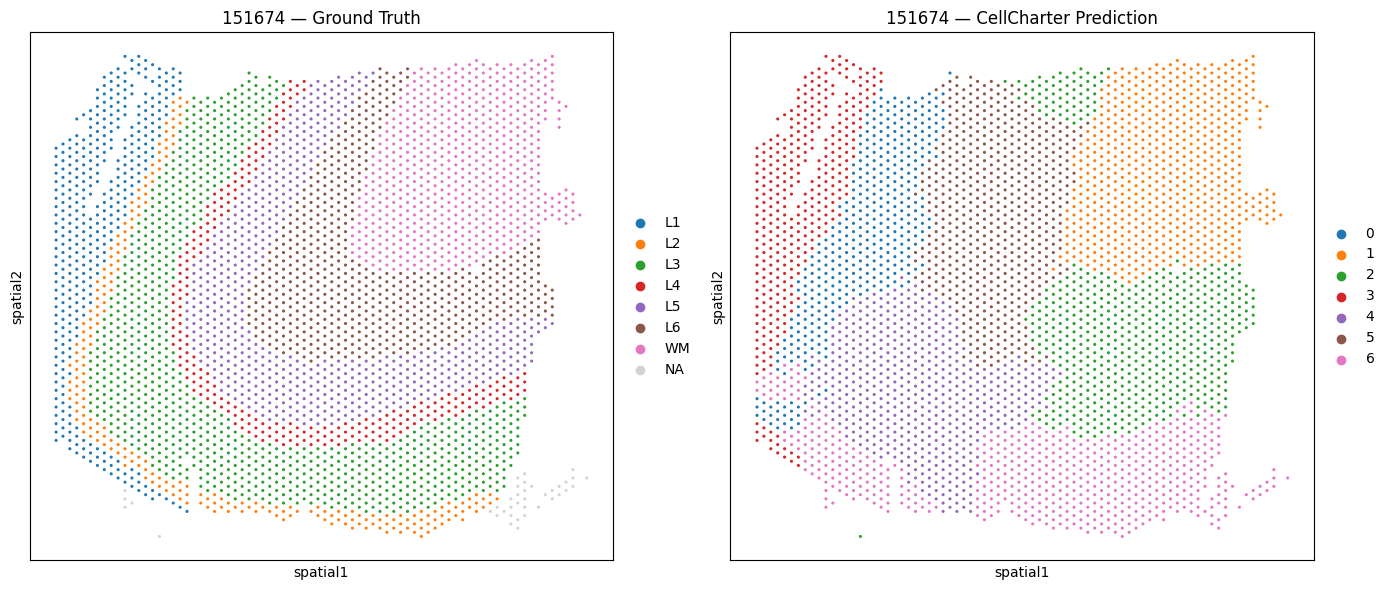

In [12]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/DLPFC_10x/data")
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/CellCharter/dlpfc_cellcharter")

SAMPLE_ID = "151674"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")
pred_slice = predictions[predictions["sample"] == SAMPLE_ID].set_index("spot_id")

adata = sc.read_h5ad(DATA_ROOT / f"SCE_{SAMPLE_ID}.h5ad")
adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

if "spatial" not in adata.obsm and "S" in adata.obsm:
    adata.obsm["spatial"] = np.asarray(adata.obsm["S"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc.pl.embedding(
    adata,
    basis="spatial",
    color="true_label",
    ax=axes[0],
    show=False,
    title=f"{SAMPLE_ID} — Ground Truth",
    s=20,
)

sc.pl.embedding(
    adata,
    basis="spatial",
    color="pred_label",
    ax=axes[1],
    show=False,
    title=f"{SAMPLE_ID} — CellCharter Prediction",
    s=20,
)

axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


# Running results summary


In [10]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/CellCharter/dlpfc_cellcharter")

perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)
performance = performance.sort_values(["sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "sample", "run_seed", "ARI", "NMI", "ACC", "HOM", "COM", "V_measure",
    "num_clusters", "num_spots", "num_labeled_spots",
    "num_genes_after_hvg", "scvi_n_latent", "cellcharter_dim", "n_layers",
    "running_time_sec", "gpu_model"
]
display_cols = [c for c in display_cols if c in performance.columns]

print("===== All CellCharter single-sample results =====")
display(performance[display_cols])

print("\n===== Summary =====")
metric_cols = [c for c in ["ARI", "NMI", "ACC", "HOM", "COM", "V_measure", "running_time_sec"] if c in performance.columns]
display(performance[metric_cols].describe())

print("\n===== Mean metrics =====")
for col in ["ARI", "NMI", "ACC", "HOM", "COM", "V_measure"]:
    if col in performance.columns:
        print(f"Mean {col}: {performance[col].mean():.4f}")

print("\n===== Best / worst ARI =====")
if "ARI" in performance.columns and len(performance) > 0:
    best = performance.loc[performance["ARI"].idxmax()]
    worst = performance.loc[performance["ARI"].idxmin()]
    print(f"Best ARI : {best['sample']}  ARI={best['ARI']:.4f}")
    print(f"Worst ARI: {worst['sample']}  ARI={worst['ARI']:.4f}")


===== All CellCharter single-sample results =====


,sample,run_seed,ARI,NMI,ACC,HOM,COM,V_measure,num_clusters,num_spots,num_labeled_spots,num_genes_after_hvg,scvi_n_latent,cellcharter_dim,n_layers,running_time_sec,gpu_model
0,151507,0,0.412081,0.535964,0.561478,0.549191,0.523358,0.535964,7,4226,4221,2000,10,40,3,25.87,NVIDIA A30
1,151508,0,0.369733,0.508384,0.537092,0.529107,0.489223,0.508384,7,4384,4381,2000,10,40,3,21.90,NVIDIA A30
2,151509,0,0.303215,0.497000,0.474311,0.535985,0.463302,0.497000,7,4789,4788,2000,10,40,3,27.25,NVIDIA A30
3,151510,0,0.260248,0.449418,0.446137,0.486879,0.417310,0.449418,7,4634,4595,2000,10,40,3,26.01,NVIDIA A30
4,151669,0,0.185530,0.413665,0.380088,0.528065,0.340006,0.413665,7,3661,3636,2000,10,40,3,23.14,NVIDIA A30
5,151670,0,0.214320,0.401125,0.398393,0.533516,0.321376,0.401125,7,3498,3484,2000,10,40,3,23.66,NVIDIA A30
6,151671,0,0.290363,0.460647,0.413144,0.552034,0.395220,0.460647,7,4110,4093,2000,10,40,3,26.35,NVIDIA A30
7,151672,0,0.319464,0.458825,0.461934,0.535052,0.401610,0.458825,7,4015,3888,2000,10,40,3,21.06,NVIDIA A30
8,151673,0,0.235449,0.383606,0.443367,0.394007,0.373740,0.383606,7,3639,3611,2000,10,40,3,25.42,NVIDIA A30
9,151674,0,0.405928,0.527315,0.525997,0.539256,0.515891,0.527315,7,3673,3635,2000,10,40,3,28.21,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,HOM,COM,V_measure,running_time_sec
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,0.308964,0.469879,0.472365,0.517159,0.435350,0.469879,24.562500
std,0.074891,0.050356,0.058718,0.042841,0.069575,0.050356,2.268216
min,0.185530,0.383606,0.380088,0.394007,0.321376,0.383606,21.060000
25%,0.254048,0.440480,0.435812,0.515024,0.389850,0.440480,22.925000
50%,0.311339,0.477842,0.468122,0.531312,0.440306,0.477842,24.540000
75%,0.372209,0.507764,0.526529,0.536803,0.491152,0.507764,26.095000
max,0.412081,0.535964,0.561478,0.552034,0.523358,0.535964,28.210000



===== Mean metrics =====
Mean ARI: 0.3090
Mean NMI: 0.4699
Mean ACC: 0.4724
Mean HOM: 0.5172
Mean COM: 0.4353
Mean V_measure: 0.4699

===== Best / worst ARI =====
Best ARI : 151507  ARI=0.4121
Worst ARI: 151669  ARI=0.1855
